# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Mini-Project 3: Agentic Banking Assistant

**(Solution)**

**DISCLAIMER:** THIS NOTEBOOK IS PROVIDED ONLY AS A REFERENCE SOLUTION NOTEBOOK FOR THE MINI-PROJECT. THERE MAY BE OTHER POSSIBLE APPROACHES/METHODS TO ACHIEVE THE SAME RESULTS.

## Learning Objectives

At the end of the mini-project, you will be able to:

* Understand how Agentic AI can automate core banking operations
* Design tool-based systems for LLM interaction with structured data
* Build agents that interpret user queries and invoke appropriate tools
* Develop orchestration workflows between agents, tools, and databases
* Implement secure transaction handling with basic validations
* Generate structured outputs such as mini statements
* Handle filtered queries like debit/credit transaction views
* Test and validate the system using real-world scenarios


## Problem Statement

Banks and financial institutions handle a large volume of customer requests related to account information, transactions, and fund transfers. These interactions are often initiated through chat, mobile apps, or support channels and involve repetitive yet critical operations.

Currently, many banking support processes are **manual, fragmented, and query-driven**, leading to several challenges:

* **Delayed response times** for customer requests
* **Inconsistent handling** of similar queries across channels
* **Over-reliance on human intervention** for routine operations
* **Limited ability to process natural language queries efficiently**
* **Lack of seamless integration** between user interactions and backend systems

A significant portion of customer requests typically falls into the following categories:

* **Information retrieval**, such as checking account balance or viewing transactions
* **Transaction operations**, such as transferring funds between accounts
* **Filtered queries**, such as viewing only debit or credit transactions
* **Statement generation**, such as requesting a mini statement of recent activities

However, most existing systems lack the capability to:

* Automatically **understand and interpret user queries from natural language inputs**
* Dynamically **select and execute appropriate backend operations (tools)**
* Provide **consistent, accurate, and real-time responses**
* Seamlessly **integrate conversational AI with structured banking data**

*The goal is to design and develop an **AI-Based Agentic Banking System** that can:*

* Interpret user queries and map them to appropriate banking operations
* Enable intelligent agents to interact with tools for balance checks, transactions, and transfers
* Support filtered views of transaction data (debit/credit)
* Generate structured outputs such as mini statements
* Provide a unified, automated, and efficient banking assistance experience


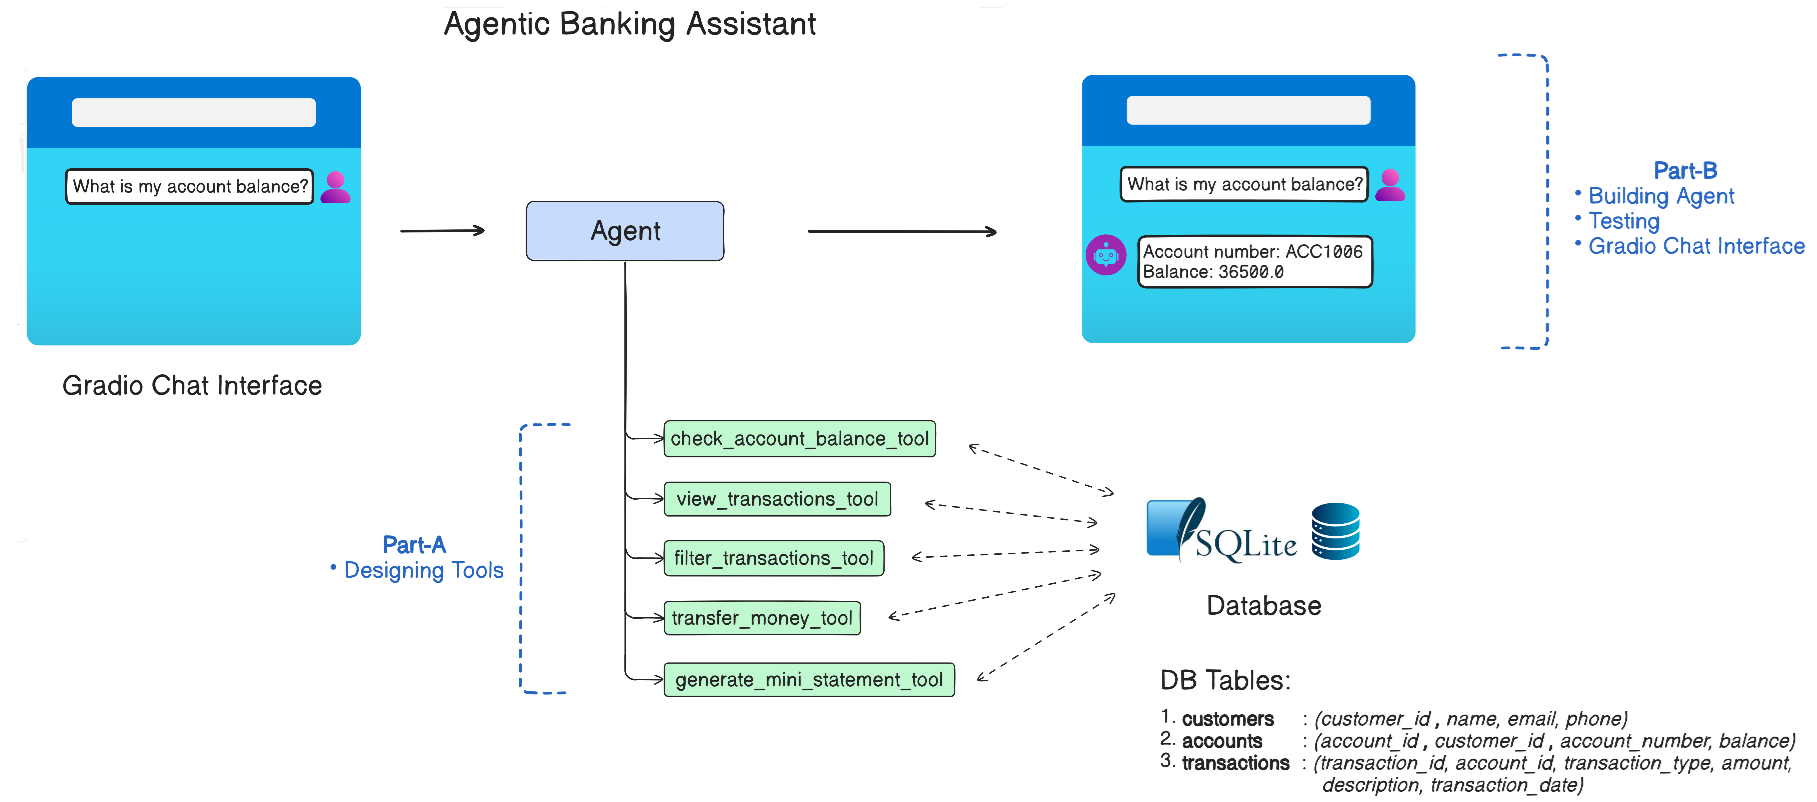

## Database Tables

Design a structured database to support all banking operations and tool interactions.

* ***customers***

  Stores basic customer details such as customer ID, name, and contact information (email).

* ***accounts***

  Maintains account-specific data including account ID, linked customer ID, and current balance.

* ***transactions***

  Records all debit and credit transactions with details like transaction ID, account ID, amount, type, and timestamp.

These tables enable efficient data retrieval, transaction processing, and support all agent-driven banking functionalities.


## Sample Input Queries to Test the System

1. Check Balance

    * *What is my current balance?*
    * *Show my account balance*
    * *How much money do I have in my account?*

---

2. See Transactions

    * *Show my recent transactions*
    * *Display last 10 transactions*
    * *Give me my transaction history*

---

3. Filter Debit/Credit

    * *Show only debit transactions*
    * *Show only credit transactions*
    * *List all my debit entries*
    * *Display my credit transactions*

---

4. Transfer Amount

    * *Transfer ₹2000 to ACC1002*
    * *Pay ₹1000 to account number ACC1002*

---

5. Mini Statement

    * *Generate my mini statement*
    * *Show last 5 transactions as a statement*
    * *Give me my mini statement for recent transactions*

---

6. Edge Case / Validation Queries

    * *Transfer ₹1,00,000 to ACC1002 (insufficient balance scenario)*
    * *Send money to an unknown user*
    * *Show transactions for last 2 years*
    * *Transfer money without specifying amount*

---

## Grading = 10 Points

- **Part-A [5 Points]**

    **Designing Tools**

    Design and implement all the necessary backend tools (functions/APIs) required to support banking operations.

    This includes creating tools for balance checking, viewing transactions, transferring funds, filtering debit/credit transactions, and generating mini statements.

    Ensure that each tool interacts correctly with the underlying database and includes essential validations such as sufficient balance checks and valid beneficiary handling.

    The focus is on building reliable, reusable, and well-structured tools that can be invoked by the agent during execution.

---

- **Part-B [5 Points]**

    **Building Agent, Testing, & Gradio Implementation**

    Design and implement the agent orchestration workflow to handle user queries and invoke appropriate tools dynamically.

    This includes building an intelligent agent capable of interpreting user intent, selecting the correct tool, managing multi-step operations (such as validation before transfer), and formatting responses.

    Also, test the complete system using sample user queries to validate accuracy, correctness, and robustness of the workflow.

    Ensure the system handles edge cases such as insufficient balance, invalid inputs, and unsupported queries effectively, providing a smooth and reliable user experience.

---

### Install Required Libraries

In [ ]:
%%capture
!pip -q install openai==2.3.0
!pip -q install langchain-core==0.3.79
!pip -q install langchain-community==0.3.31
!pip -q install sentence-transformers==5.1.1
!pip -q install langchain-huggingface==0.3.1
!pip -q install langchain-experimental==0.3.4
!pip -q install langchainhub==0.1.21
!pip -q install langchain-openai==0.3.35
!pip -q install langgraph==0.6.8

### Import Neccesary Packages

In [ ]:
import os
import sqlite3
from datetime import datetime
from google.colab import userdata

from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, create_react_agent, tools_condition
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

from typing import TypedDict, List, Optional, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

### Read the Groq API Key

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [ ]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

### Initialize LLM

***Note:** Groq models have [rate limits](https://console.groq.com/docs/rate-limits)—you can use alternative models from other providers if required.*

In [ ]:
llm = ChatOpenAI(
    model="openai/gpt-oss-120b",   # Groq-supported model
    temperature=0,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

### **Create a SQLite Database (in-memory)**

**SQLite** is a C library that provides a lightweight disk-based database that doesn't require a separate server process and allows accessing the database using a nonstandard variant of the SQL query language. Some applications can use SQLite for internal data storage.

SQLite3 specifically refers to the third version of SQLite.

*You may use the provided sample database created below and modify the tables or data if required.*

In [ ]:
import sqlite3
# --- SQLite DB ---
DB_FILE = "banking_system.db"


def init_db():

    # Create / connect to SQLite database
    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    # Enable foreign key support
    cursor.execute("PRAGMA foreign_keys = ON;")

    # -----------------------------
    # Create Tables
    # -----------------------------

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS customers (
        customer_id TEXT PRIMARY KEY,
        name TEXT NOT NULL,
        email TEXT,
        phone TEXT
    );
    """)

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS accounts (
        account_id TEXT PRIMARY KEY,
        customer_id TEXT NOT NULL,
        account_number TEXT UNIQUE NOT NULL,
        balance REAL NOT NULL,
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
    );
    """)

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS transactions (
        transaction_id TEXT PRIMARY KEY,
        account_id TEXT NOT NULL,
        transaction_type TEXT NOT NULL CHECK(transaction_type IN ('debit', 'credit')),
        amount REAL NOT NULL,
        description TEXT,
        transaction_timestamp TEXT NOT NULL,
        FOREIGN KEY (account_id) REFERENCES accounts(account_id)
    );
    """)

    # -----------------------------
    # Insert Sample Data
    # -----------------------------

    customers_data = [
        ("C1", "Aarav Sharma", "aarav@example.com", "9876543210"),
        ("C2", "Rahul Verma", "rahul@example.com", "9876501234"),
        ("C3", "Priya Mehta", "priya@example.com", "9876512345"),
        ("C4", "Neha Kapoor", "neha@example.com", "9876523456"),
        ("C5", "Rohan Singh", "rohan@example.com", "9876534567"),
        ("C6", "Ananya Gupta", "ananya@example.com", "9876545678")
    ]

    accounts_data = [
        ("A1", "C1", "ACC1001", 48300.00),
        ("A2", "C2", "ACC1002", 28300.00),
        ("A3", "C3", "ACC1003", 43500.00),
        ("A4", "C4", "ACC1004", 0.00),
        ("A5", "C5", "ACC1005", 55300.00),
        ("A6", "C6", "ACC1006", 36500.00)
    ]

    transactions_data = [
        # Aarav
        ("T1", "A1", "credit", 50000.00, "Salary credited", "2026-05-01 10:00:00"),
        ("T2", "A1", "debit", 2500.00, "Online shopping", "2026-05-02 14:30:00"),
        ("T3", "A1", "debit", 1200.00, "Electricity bill", "2026-05-03 09:15:00"),
        ("T4", "A1", "credit", 5000.00, "Refund received", "2026-05-04 16:45:00"),
        ("T5", "A1", "debit", 3000.00, "Restaurant", "2026-05-05 20:10:00"),

        # Rahul
        ("T6", "A2", "credit", 30000.00, "Salary credited", "2026-05-01 10:10:00"),
        ("T7", "A2", "debit", 1500.00, "Mobile recharge", "2026-05-03 12:00:00"),
        ("T8", "A2", "debit", 2200.00, "Groceries", "2026-05-04 18:20:00"),
        ("T9", "A2", "credit", 2000.00, "Cashback", "2026-05-05 11:00:00"),

        # Priya
        ("T10", "A3", "credit", 45000.00, "Salary credited", "2026-05-01 10:20:00"),
        ("T11", "A3", "debit", 2200.00, "Grocery purchase", "2026-05-04 18:30:00"),
        ("T12", "A3", "debit", 1500.00, "Uber rides", "2026-05-05 09:00:00"),
        ("T13", "A3", "credit", 3000.00, "Freelance payment", "2026-05-06 13:15:00"),
        ("T14", "A3", "debit", 800.00, "Coffee shop", "2026-05-06 18:45:00"),

        # Rohan
        ("T15", "A5", "credit", 60000.00, "Salary credited", "2026-05-01 09:30:00"),
        ("T16", "A5", "debit", 5000.00, "Flight booking", "2026-05-02 08:45:00"),
        ("T17", "A5", "debit", 2500.00, "Hotel booking", "2026-05-03 21:10:00"),
        ("T18", "A5", "credit", 4000.00, "Bonus", "2026-05-05 10:00:00"),
        ("T19", "A5", "debit", 1200.00, "Fuel", "2026-05-06 08:30:00"),

        # Ananya
        ("T20", "A6", "credit", 40000.00, "Salary credited", "2026-05-01 10:50:00"),
        ("T21", "A6", "debit", 3000.00, "Shopping", "2026-05-05 17:10:00"),
        ("T22", "A6", "debit", 2000.00, "Gym membership", "2026-05-06 07:30:00"),
        ("T23", "A6", "credit", 1500.00, "Cashback", "2026-05-06 14:00:00")
    ]

    # Insert data
    cursor.executemany("""
    INSERT OR IGNORE INTO customers
    (customer_id, name, email, phone)
    VALUES (?, ?, ?, ?);
    """, customers_data)

    cursor.executemany("""
    INSERT OR IGNORE INTO accounts
    (account_id, customer_id, account_number, balance)
    VALUES (?, ?, ?, ?);
    """, accounts_data)

    cursor.executemany("""
    INSERT OR IGNORE INTO transactions
    (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp)
    VALUES (?, ?, ?, ?, ?, ?);
    """, transactions_data)

    # Commit changes
    conn.commit()

    print("Database created and populated successfully!")

    # Verify tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    print("Tables:", cursor.fetchall())

    conn.close()


init_db()

Database created and populated successfully!
Tables: [('customers',), ('accounts',), ('transactions',)]


In [ ]:
# Function that executes a SQL query on the SQLite database and returns the result set

def sql_query(query):
    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()
    cursor.execute(query)
    return cursor.fetchall()

In [ ]:
sql_query("SELECT * FROM customers")

[('C1', 'Aarav Sharma', 'aarav@example.com', '9876543210'),
 ('C2', 'Rahul Verma', 'rahul@example.com', '9876501234'),
 ('C3', 'Priya Mehta', 'priya@example.com', '9876512345'),
 ('C4', 'Neha Kapoor', 'neha@example.com', '9876523456'),
 ('C5', 'Rohan Singh', 'rohan@example.com', '9876534567'),
 ('C6', 'Ananya Gupta', 'ananya@example.com', '9876545678')]

In [ ]:
sql_query("SELECT * FROM accounts")

[('A1', 'C1', 'ACC1001', 48300.0),
 ('A2', 'C2', 'ACC1002', 28300.0),
 ('A3', 'C3', 'ACC1003', 43500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 36500.0)]

In [ ]:
sql_query("SELECT * FROM transactions")

[('T1', 'A1', 'credit', 50000.0, 'Salary credited', '2026-05-01 10:00:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00'),
 ('T3', 'A1', 'debit', 1200.0, 'Electricity bill', '2026-05-03 09:15:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T6', 'A2', 'credit', 30000.0, 'Salary credited', '2026-05-01 10:10:00'),
 ('T7', 'A2', 'debit', 1500.0, 'Mobile recharge', '2026-05-03 12:00:00'),
 ('T8', 'A2', 'debit', 2200.0, 'Groceries', '2026-05-04 18:20:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T10', 'A3', 'credit', 45000.0, 'Salary credited', '2026-05-01 10:20:00'),
 ('T11', 'A3', 'debit', 2200.0, 'Grocery purchase', '2026-05-04 18:30:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00'),
 ('T13', 'A3', 'credit', 3000.0, 'Freelance payment', '2026-05-06 13:15:00'),
 ('T14', 'A3', 'debit', 800.0, 'Coffee shop'

In [ ]:
sql_query("""SELECT *
FROM transactions
WHERE DATE(transaction_timestamp) = '2026-05-05'
ORDER BY transaction_timestamp DESC;""")

[('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T21', 'A6', 'debit', 3000.0, 'Shopping', '2026-05-05 17:10:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T18', 'A5', 'credit', 4000.0, 'Bonus', '2026-05-05 10:00:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00')]

In [ ]:
sql_query("""SELECT *
FROM transactions
WHERE TIME(transaction_timestamp) BETWEEN '14:00:00' AND '17:00:00'
ORDER BY transaction_timestamp DESC;""")

[('T23', 'A6', 'credit', 1500.0, 'Cashback', '2026-05-06 14:00:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00')]

# **Part-A** Designing Tools

### **1. Tool to Check Account Balance** -- [1 Point]

This tool is responsible for retrieving the current account balance of a customer using their `customer_id`. It connects to the database, fetches the corresponding account details, and returns a formatted response. The tool must handle both valid and invalid inputs while ensuring proper database interaction and clean output formatting.

**Steps to implement:**

* Accept `customer_id` as input from the user/agent
* Establish a connection to the SQLite database
* Execute a parameterized SQL query to fetch `account_number` and `balance`
* Check if a matching record exists

  * If found → return account number and balance
  * If not found → return an appropriate error message
* Print logs for tool invocation, input parameters, and output (for debugging)
* Close the database connection after execution


In [ ]:
# 1. Check Account Balance

# Create function to check the account balance
def check_account_balance(customer_id: str):
    """
    Returns the current account balance for a given customer.
    """

    print(f" CALLING Tool: check_account_balance()")
    print(f" PARAMS: customer_id='{customer_id}'")

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT a.account_number, a.balance
        FROM accounts a
        WHERE a.customer_id = ?
    """, (customer_id,))

    result = cursor.fetchone()
    conn.close()

    if result:
        print(f"Tool Output: Account_number: {result[0]} | Balance: {result[1]}\n")
        return f"Account_number: {result[0]} | Balance: {result[1]}"
    else:
        print(f"Tool Output: Customer account not found for this Customer Id: {customer_id}\n")
        return f"Customer account not found for this Customer Id: {customer_id}"


In [ ]:
# Test the function for a valid customer id
check_account_balance("C6")

 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C6'
Tool Output: Account_number: ACC1006 | Balance: 36500.0



'Account_number: ACC1006 | Balance: 36500.0'

In [ ]:
# Test the function for an invalid customer id
check_account_balance("C12")

 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C12'
Tool Output: Customer account not found for this Customer Id: C12



'Customer account not found for this Customer Id: C12'

In [ ]:
# Create a Tool for checking account balance, to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

check_account_balance_tool = StructuredTool.from_function(
    name="check_account_balance_tool",
    description="""Use this tool to check the current account balance of a customer. \
    The input should always be a string representing the customer_id. \
    This tool returns the account number and current balance for the given customer.""",
    func=check_account_balance,
)

In [ ]:
# Test the tool for a valid customer id
check_account_balance_tool.run({
    "customer_id": "C6"
})

 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C6'
Tool Output: Account_number: ACC1006 | Balance: 36500.0



'Account_number: ACC1006 | Balance: 36500.0'

In [ ]:
# Test the tool for an invalid customer id
check_account_balance_tool.run({
    "customer_id": "C12"
})

 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C12'
Tool Output: Customer account not found for this Customer Id: C12



'Customer account not found for this Customer Id: C12'

### **2. Tool to View Transactions** -- [1 Point]

This tool retrieves the recent transaction history for a given customer based on the provided `customer_id`. It ensures that the customer exists, fetches the latest transactions from the database, and returns them in a structured tabular format. The tool also handles cases where the customer is invalid or has no transaction history.

**Steps to implement:**

* Accept `customer_id` and optional `limit` (default = 10) as input
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Execute a SQL query to fetch recent transactions by joining `accounts` and `transactions` tables
* Sort transactions in descending order based on timestamp and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Format the transaction data into a readable tabular structure
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [ ]:
# 2. View Transactions

# Create function to view transactions
def view_transactions(customer_id: str, limit: int = 10):
    """
    Returns recent transactions for a given customer.
    Handles:
    - Invalid customer_id
    - No transactions case
    """

    print(f" CALLING Tool: view_transactions()")
    print(f" PARAMS: customer_id='{customer_id}', limit={limit}")

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    # Step 1: Check if customer exists
    cursor.execute("""
        SELECT 1 FROM customers WHERE customer_id = ?
    """, (customer_id,))

    customer_exists = cursor.fetchone()

    if not customer_exists:
        conn.close()
        print(f"Tool Output: Invalid customer_id {customer_id}. Customer does not exist.\n")
        return f"Invalid customer_id {customer_id}. Customer does not exist."

    # Step 2: Fetch transactions
    cursor.execute("""
        SELECT
            t.transaction_id,
            t.transaction_type,
            t.amount,
            t.description,
            t.transaction_timestamp
        FROM transactions t
        JOIN accounts a ON t.account_id = a.account_id
        WHERE a.customer_id = ?
        ORDER BY t.transaction_timestamp DESC
        LIMIT ?
    """, (customer_id, limit))

    rows = cursor.fetchall()
    conn.close()

    # Step 3: Handle no transactions case
    if not rows:
        print(f"Tool Output: No transactions found for this customer with Customer Id: {customer_id}.\n")
        return f"No transactions found for this customer with Customer Id: {customer_id}."

    # Step 4: Return transactions in tabular format
    transactions = [
        {
            "transaction_id": row[0],
            "transaction_type": row[1],
            "amount": row[2],
            "description": row[3],
            "transaction_timestamp": row[4]
        }
        for row in rows
    ]

    # Create table header
    table = "\n"
    table += f"{'Txn ID':<8} {'Type':<8} {'Amount':<10} {'Description':<25} {'Timestamp':<20}\n"
    table += "-" * 75 + "\n"

    # Add rows
    for txn in transactions:
        table += f"{txn['transaction_id']:<8} {txn['transaction_type']:<8} {txn['amount']:<10} {txn['description']:<25} {txn['transaction_timestamp']:<20}\n"

    print(f"Tool Output: {table}\n")
    return table



In [ ]:
# Test the function for a valid customer id
print(view_transactions("C6"))

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C6', limit=10
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 
T20      credit   40000.0    Salary credited           2026-05-01 10:50:00 



Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 
T20      credit   40000.0    Salary credited           2026-05-01 10:50:00 


In [ ]:
# Test the function for a valid customer id & limit parameter
print(view_transactions("C6", 2))

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C6', limit=2
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 



Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 



In [ ]:
# Test the function for a valid customer id, with No transactions
view_transactions("C4")

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C4', limit=10
Tool Output: No transactions found for this customer with Customer Id: C4.



'No transactions found for this customer with Customer Id: C4.'

In [ ]:
# Test the function for an invalid customer id
view_transactions("C12")

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C12', limit=10
Tool Output: Invalid customer_id C12. Customer does not exist.



'Invalid customer_id C12. Customer does not exist.'

In [ ]:
# Create a Tool for viewing recent transactions, to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

view_transactions_tool = StructuredTool.from_function(
    name="view_transactions_tool",
    description="""Use this tool when the user asks to view recent transactions or transaction history. \
    The input should include:
      - customer_id (string)
      - limit (optional integer, default = 10)
    This tool returns recent transactions in a tabular format including:
    transaction id, type (debit/credit), amount, description, and timestamp.
    It also handles:
      - Invalid customer_id
      - No transactions found cases""",
    func=view_transactions,
)

In [ ]:
# Test the tool for a valid customer id
view_transactions_tool.run({
    "customer_id": "C6",
    "limit": 2
})

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C6', limit=2
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 




'\nTxn ID   Type     Amount     Description               Timestamp           \n---------------------------------------------------------------------------\nT23      credit   1500.0     Cashback                  2026-05-06 14:00:00 \nT22      debit    2000.0     Gym membership            2026-05-06 07:30:00 \n'

In [ ]:
# Test the tool for a valid customer id with No transactions
view_transactions_tool.run({
    "customer_id": "C4",
    "limit": 2
})

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C4', limit=2
Tool Output: No transactions found for this customer with Customer Id: C4.



'No transactions found for this customer with Customer Id: C4.'

### **3. Tool to Filter Transactions Debit/Credit** -- [1 Point]

This tool retrieves filtered transaction history for a given customer based on the specified `transaction_type` (debit or credit). It validates the input parameters, ensures the customer exists, and returns the filtered transactions in a structured tabular format. The tool also handles invalid inputs and cases where no transactions are found.

**Steps to implement:**

* Accept `customer_id`, `transaction_type` (debit/credit), and optional `limit` (default = 10) as input
* Convert `transaction_type` to lowercase and validate it

  * If invalid → return an error message
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Execute a SQL query to fetch transactions by joining `accounts` and `transactions` tables

  * Apply filter on `transaction_type`
  * Sort by timestamp in descending order and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Format the filtered transactions into a readable tabular structure
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [ ]:
# 3. Filter Transactions Debit/Credit

# Create function to filter transactions
def filter_transactions(customer_id: str, transaction_type: str, limit: int = 10):
    """
    Returns only debit or credit transactions for a customer.
    """

    print(f" CALLING Tool: filter_transactions()")
    print(f" PARAMS: customer_id='{customer_id}', transaction_type='{transaction_type}', limit={limit}")

    transaction_type = transaction_type.lower()

    if transaction_type not in ["debit", "credit"]:
        print("Tool Output: transaction_type must be either 'debit' or 'credit'.\n")
        return "transaction_type must be either 'debit' or 'credit'."

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    # Check if customer exists
    cursor.execute("""
        SELECT 1 FROM customers WHERE customer_id = ?
    """, (customer_id,))

    customer_exists = cursor.fetchone()

    if not customer_exists:
        conn.close()
        print(f"Tool Output: Invalid customer_id {customer_id}. Customer does not exist.\n")
        return f"Invalid customer_id {customer_id}. Customer does not exist."


    cursor.execute("""
        SELECT
            t.transaction_id,
            t.transaction_type,
            t.amount,
            t.description,
            t.transaction_timestamp
        FROM transactions t
        JOIN accounts a ON t.account_id = a.account_id
        WHERE a.customer_id = ?
          AND t.transaction_type = ?
        ORDER BY t.transaction_timestamp DESC
        LIMIT ?
    """, (customer_id, transaction_type, limit))

    rows = cursor.fetchall()
    conn.close()

    # Convert rows into table format

    if not rows:
        print("Tool Output: No transactions found.\n")
        return "No transactions found."

    # Create table header
    table = "\n"
    table += f"{'Txn ID':<8} {'Type':<8} {'Amount':<10} {'Description':<25} {'Timestamp':<20}\n"
    table += "-" * 75 + "\n"

    # Add rows
    for row in rows:
        table += f"{row[0]:<8} {row[1]:<8} {row[2]:<10} {row[3]:<25} {row[4]:<20}\n"

    print(f"Tool Output: {table}\n")
    return table


In [ ]:
# Test the function for a valid customer id and transaction type
print(filter_transactions("C6", "debit"))

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='debit', limit=10
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 



Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 



In [ ]:
print(filter_transactions("C6", "credit"))

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='credit', limit=10
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T20      credit   40000.0    Salary credited           2026-05-01 10:50:00 



Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T20      credit   40000.0    Salary credited           2026-05-01 10:50:00 



In [ ]:
# Test the function for a valid customer id and transaction type, with No transactions
print(filter_transactions("C4", "debit"))

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C4', transaction_type='debit', limit=10
Tool Output: No transactions found.

No transactions found.


In [ ]:
# Test the function for a valid customer id and and invalid transaction type
print(filter_transactions("C6", "debitted"))

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='debitted', limit=10
Tool Output: transaction_type must be either 'debit' or 'credit'.

transaction_type must be either 'debit' or 'credit'.


In [ ]:
# Test the function for an invalid customer id
print(filter_transactions("C12", "debit"))

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C12', transaction_type='debit', limit=10
Tool Output: Invalid customer_id C12. Customer does not exist.

Invalid customer_id C12. Customer does not exist.


In [ ]:
# Create a Tool for filtering transactions (debit/credit), to be used by the agent for tool calling

# Use Structured Tool for multi-parameter function
from langchain_core.tools import StructuredTool

filter_transactions_tool = StructuredTool.from_function(
    name="filter_transactions_tool",
    description="""Use this tool when the user asks to view only debit or credit transactions.
    The input should include:
    - customer_id (string)
    - transaction_type (string: 'debit' or 'credit')
    - limit (optional integer, default = 10)

    This tool returns filtered transactions in a tabular format including:
    transaction id, type, amount, description, and timestamp.

    It also handles:
    - Invalid customer_id
    - Invalid transaction_type
    - No transactions found cases""",
    func=filter_transactions,
)

In [ ]:
# Test the tool for a valid customer id and transaction type
filter_transactions_tool.run({
    "customer_id": "C6",
    "transaction_type": "debit",
    "limit": 2
})

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='debit', limit=2
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 




'\nTxn ID   Type     Amount     Description               Timestamp           \n---------------------------------------------------------------------------\nT22      debit    2000.0     Gym membership            2026-05-06 07:30:00 \nT21      debit    3000.0     Shopping                  2026-05-05 17:10:00 \n'

In [ ]:
# Test the tool for a valid customer id and invalid transaction type
filter_transactions_tool.run({
    "customer_id": "C6",
    "transaction_type": "debitted",
    "limit": 2
})

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='debitted', limit=2
Tool Output: transaction_type must be either 'debit' or 'credit'.



"transaction_type must be either 'debit' or 'credit'."

In [ ]:
# Test the tool for a valid customer id and transaction type, with No transactions
filter_transactions_tool.run({
    "customer_id": "C4",
    "transaction_type": "debit",
    "limit": 2
})

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C4', transaction_type='debit', limit=2
Tool Output: No transactions found.



'No transactions found.'

### **4. Tool to Transfer Money** -- [1 Point]

This tool enables transferring money from one customer’s account to another account using the provided sender customer ID, receiver account number, and transfer amount. It performs necessary validations such as checking sender account existence, receiver account validity, sufficient balance, and positive transfer amount. The tool updates account balances, records transactions, and ensures data consistency using database operations.

**Steps to implement:**

* Accept `sender_customer_id`, `receiver_account_number`, and `amount` as input
* Validate that the transfer `amount` is greater than zero

  * If invalid → return an error message
* Establish a connection to the SQLite database
* Fetch sender account details using `customer_id`

  * If not found → return an error message
* Fetch receiver account details using `account_number`

  * If not found → return an error message
* Check if sender has sufficient balance

  * If insufficient → return an error message
* Generate current timestamp for transaction records
* Debit the sender’s account and credit the receiver’s account
* Insert corresponding debit and credit entries into the `transactions` table
* Commit the transaction to ensure changes are saved
* Handle exceptions using rollback in case of errors
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [ ]:
# 4. Transfer Money

# Create function to tranfer money
def transfer_money(sender_customer_id: str, receiver_account_number: str, amount: float):
    """
    Transfers money from one customer's account to another account.
    Performs validation for amount, sender balance, and receiver existence.
    """

    print(f" CALLING Tool: transfer_money()")
    print(f" PARAMS: sender_customer_id='{sender_customer_id}', receiver_account_number='{receiver_account_number}', amount={amount}")

    if amount <= 0:
        print("Tool Output: Transfer amount must be greater than zero.\n")
        return "Transfer amount must be greater than zero."

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    try:
        # Get sender account
        cursor.execute("""
            SELECT account_id, balance
            FROM accounts
            WHERE customer_id = ?
        """, (sender_customer_id,))
        sender = cursor.fetchone()

        if not sender:
            print(f"Tool Output: Sender account not found for the Customer Id: {sender_customer_id}.\n")
            return f"Sender account not found for the Customer Id: {sender_customer_id}."

        sender_account_id, sender_balance = sender

        # Get receiver account
        cursor.execute("""
            SELECT account_id
            FROM accounts
            WHERE account_number = ?
        """, (receiver_account_number,))
        receiver = cursor.fetchone()

        if not receiver:
            print(f"Tool Output: Receiver account not found for the Account number: {receiver_account_number}.\n")
            return f"Receiver account not found for the Account number: {receiver_account_number}."

        receiver_account_id = receiver[0]

        if sender_balance < amount:
            print("Tool Output: Insufficient balance.\n")
            return "Insufficient balance."

        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # Debit sender
        cursor.execute("""
            UPDATE accounts
            SET balance = balance - ?
            WHERE account_id = ?
        """, (amount, sender_account_id))

        # Credit receiver
        cursor.execute("""
            UPDATE accounts
            SET balance = balance + ?
            WHERE account_id = ?
        """, (amount, receiver_account_id))

        # Insert debit transaction
        curr_txn_rows = sql_query("SELECT count(*) FROM transactions;")[0][0]
        cursor.execute("""
            INSERT INTO transactions
            (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp)
            VALUES (?, ?, 'debit', ?, ?, ?)
        """, (
            "T" + str(curr_txn_rows + 1),
            sender_account_id,
            amount,
            f"Transfer to {receiver_account_number}",
            timestamp
        ))

        # Insert credit transaction
        cursor.execute("""
            INSERT INTO transactions
            (transaction_id, account_id, transaction_type, amount, description, transaction_timestamp)
            VALUES (?, ?, 'credit', ?, ?, ?)
        """, (
            "T" + str(curr_txn_rows + 2),
            receiver_account_id,
            amount,
            f"Transfer from customer {sender_customer_id}",
            timestamp
        ))

        conn.commit()

        print(f"Tool Output: ₹{amount} transferred successfully to {receiver_account_number}.\n")
        return f"₹{amount} transferred successfully to {receiver_account_number}."

    except Exception as e:
        conn.rollback()
        return {"error": str(e)}

    finally:
        conn.close()



In [ ]:
sql_query("SELECT * FROM accounts;")

[('A1', 'C1', 'ACC1001', 48300.0),
 ('A2', 'C2', 'ACC1002', 28300.0),
 ('A3', 'C3', 'ACC1003', 43500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 36500.0)]

In [ ]:
sql_query("SELECT * FROM transactions;")

[('T1', 'A1', 'credit', 50000.0, 'Salary credited', '2026-05-01 10:00:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00'),
 ('T3', 'A1', 'debit', 1200.0, 'Electricity bill', '2026-05-03 09:15:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T6', 'A2', 'credit', 30000.0, 'Salary credited', '2026-05-01 10:10:00'),
 ('T7', 'A2', 'debit', 1500.0, 'Mobile recharge', '2026-05-03 12:00:00'),
 ('T8', 'A2', 'debit', 2200.0, 'Groceries', '2026-05-04 18:20:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T10', 'A3', 'credit', 45000.0, 'Salary credited', '2026-05-01 10:20:00'),
 ('T11', 'A3', 'debit', 2200.0, 'Grocery purchase', '2026-05-04 18:30:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00'),
 ('T13', 'A3', 'credit', 3000.0, 'Freelance payment', '2026-05-06 13:15:00'),
 ('T14', 'A3', 'debit', 800.0, 'Coffee shop'

In [ ]:
# Test the function for valid entries
transfer_money(
    sender_customer_id="C6",
    receiver_account_number="ACC1002",
    amount=1000
)

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC1002', amount=1000
Tool Output: ₹1000 transferred successfully to ACC1002.



'₹1000 transferred successfully to ACC1002.'

In [ ]:
sql_query("SELECT * FROM accounts;")

[('A1', 'C1', 'ACC1001', 48300.0),
 ('A2', 'C2', 'ACC1002', 29300.0),
 ('A3', 'C3', 'ACC1003', 43500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 35500.0)]

In [ ]:
sql_query("SELECT * FROM transactions;")

[('T1', 'A1', 'credit', 50000.0, 'Salary credited', '2026-05-01 10:00:00'),
 ('T2', 'A1', 'debit', 2500.0, 'Online shopping', '2026-05-02 14:30:00'),
 ('T3', 'A1', 'debit', 1200.0, 'Electricity bill', '2026-05-03 09:15:00'),
 ('T4', 'A1', 'credit', 5000.0, 'Refund received', '2026-05-04 16:45:00'),
 ('T5', 'A1', 'debit', 3000.0, 'Restaurant', '2026-05-05 20:10:00'),
 ('T6', 'A2', 'credit', 30000.0, 'Salary credited', '2026-05-01 10:10:00'),
 ('T7', 'A2', 'debit', 1500.0, 'Mobile recharge', '2026-05-03 12:00:00'),
 ('T8', 'A2', 'debit', 2200.0, 'Groceries', '2026-05-04 18:20:00'),
 ('T9', 'A2', 'credit', 2000.0, 'Cashback', '2026-05-05 11:00:00'),
 ('T10', 'A3', 'credit', 45000.0, 'Salary credited', '2026-05-01 10:20:00'),
 ('T11', 'A3', 'debit', 2200.0, 'Grocery purchase', '2026-05-04 18:30:00'),
 ('T12', 'A3', 'debit', 1500.0, 'Uber rides', '2026-05-05 09:00:00'),
 ('T13', 'A3', 'credit', 3000.0, 'Freelance payment', '2026-05-06 13:15:00'),
 ('T14', 'A3', 'debit', 800.0, 'Coffee shop'

In [ ]:
# Test the function for insufficient balance
transfer_money(
    sender_customer_id="C6",
    receiver_account_number="ACC1002",
    amount=90000
)

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC1002', amount=90000
Tool Output: Insufficient balance.



'Insufficient balance.'

In [ ]:
# Test the function for invalid sender
transfer_money(
    sender_customer_id="C12",
    receiver_account_number="ACC1002",
    amount=1000
)

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C12', receiver_account_number='ACC1002', amount=1000
Tool Output: Sender account not found for the Customer Id: C12.



'Sender account not found for the Customer Id: C12.'

In [ ]:
# Test the function for invalid receiver
transfer_money(
    sender_customer_id="C6",
    receiver_account_number="ACC4002",
    amount=1000
)

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC4002', amount=1000
Tool Output: Receiver account not found for the Account number: ACC4002.



'Receiver account not found for the Account number: ACC4002.'

In [ ]:
# Test the function for invalid amount
transfer_money(
    sender_customer_id="C6",
    receiver_account_number="ACC4002",
    amount=-1500
)

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC4002', amount=-1500
Tool Output: Transfer amount must be greater than zero.



'Transfer amount must be greater than zero.'

In [ ]:
# Create a StructuredTool for transferring money, to be used by the agent for tool calling
from langchain_core.tools import StructuredTool

transfer_money_tool = StructuredTool.from_function(
    name="transfer_money_tool",
    description="""Use this tool when the user wants to transfer money from one account to another.
    Inputs:
    - sender_customer_id (string): Customer ID of the sender
    - receiver_account_number (string): Account number of the receiver
    - amount (float): Amount to be transferred
    This tool performs:
    - Sender account validation
    - Receiver account validation
    - Sufficient balance check
    - Debit from sender account
    - Credit to receiver account
    - Transaction records creation
    Returns a success message if the transfer is completed, otherwise returns an error message.""",
    func=transfer_money,
)

In [ ]:
sql_query("SELECT * FROM accounts;")

[('A1', 'C1', 'ACC1001', 48300.0),
 ('A2', 'C2', 'ACC1002', 29300.0),
 ('A3', 'C3', 'ACC1003', 43500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 35500.0)]

In [ ]:
# Test the tool for valid entries
transfer_money_tool.run({
    "sender_customer_id": "C6",
    "receiver_account_number": "ACC1002",
    "amount": 1000
})

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC1002', amount=1000.0
Tool Output: ₹1000.0 transferred successfully to ACC1002.



'₹1000.0 transferred successfully to ACC1002.'

In [ ]:
sql_query("SELECT * FROM accounts;")

[('A1', 'C1', 'ACC1001', 48300.0),
 ('A2', 'C2', 'ACC1002', 30300.0),
 ('A3', 'C3', 'ACC1003', 43500.0),
 ('A4', 'C4', 'ACC1004', 0.0),
 ('A5', 'C5', 'ACC1005', 55300.0),
 ('A6', 'C6', 'ACC1006', 34500.0)]

In [ ]:
sql_query("SELECT * FROM transactions;")[-6:]

[('T22', 'A6', 'debit', 2000.0, 'Gym membership', '2026-05-06 07:30:00'),
 ('T23', 'A6', 'credit', 1500.0, 'Cashback', '2026-05-06 14:00:00'),
 ('T24', 'A6', 'debit', 1000.0, 'Transfer to ACC1002', '2026-05-05 15:39:31'),
 ('T25',
  'A2',
  'credit',
  1000.0,
  'Transfer from customer C6',
  '2026-05-05 15:39:31'),
 ('T26', 'A6', 'debit', 1000.0, 'Transfer to ACC1002', '2026-05-05 15:40:19'),
 ('T27',
  'A2',
  'credit',
  1000.0,
  'Transfer from customer C6',
  '2026-05-05 15:40:19')]

In [ ]:
# Test the tool for insufficient balance
transfer_money_tool.run({
    "sender_customer_id": "C6",
    "receiver_account_number": "ACC1002",
    "amount": 90000
})

 CALLING Tool: transfer_money()
 PARAMS: sender_customer_id='C6', receiver_account_number='ACC1002', amount=90000.0
Tool Output: Insufficient balance.



'Insufficient balance.'

### **5. Tool to Generate Mini Statement** -- [1 Point]

This tool generates a mini statement for a given customer by retrieving recent transactions, calculating the running balance, and presenting the information in a structured, bank-style format. It validates the customer and account details, fetches the latest transactions, and formats the output to provide a clear snapshot of account activity.

**Steps to implement:**

* Accept `customer_id` and optional `limit` (default = 5) as input
* Establish a connection to the SQLite database
* Validate whether the given `customer_id` exists in the `customers` table

  * If not → return an error message
* Fetch account details (`account_id`, `account_number`, `balance`)

  * If not found → return an error message
* Mask the account number for secure display (eg. XXXX1006)
* Execute a SQL query to retrieve the latest transactions for the account

  * Sort by timestamp in descending order and limit the results
* Check if any transactions are returned

  * If none → return a “No transactions found” message
* Calculate running balance in reverse order based on current balance
* Format the output into a structured mini statement including:

  * Customer details
  * Account number (masked)
  * Generated timestamp
  * Transaction table with date, type, amount, balance, and description
  * Current balance
* Print logs for tool invocation, parameters, and output (for debugging)
* Close the database connection after execution


In [ ]:
# 5. Generate Mini Statement

# Create function to generate mini statement
def generate_mini_statement(customer_id: str, limit: int = 5):
    """
    Generates a mini statement with:
    - Account details
    - Last N transactions
    - Running balance
    - Formatted output
    """

    print(f" CALLING Tool: generate_mini_statement()")
    print(f" PARAMS: customer_id='{customer_id}', limit='{limit}'")

    conn = sqlite3.connect(DB_FILE)
    cursor = conn.cursor()

    # Step 1: Validate customer
    cursor.execute("SELECT name FROM customers WHERE customer_id = ?", (customer_id,))
    customer = cursor.fetchone()

    if not customer:
        conn.close()
        print(f"Tool Output: Invalid customer_id {customer_id}\n")
        return f"Invalid customer_id {customer_id}"

    customer_name = customer[0]

    # Step 2: Get account details
    cursor.execute("""
        SELECT account_id, account_number, balance
        FROM accounts
        WHERE customer_id = ?
    """, (customer_id,))
    account = cursor.fetchone()

    if not account:
        conn.close()
        print(f"Tool Output: Account not found for this customer with Customer Id: {customer_id}\n")
        return f"Account not found for this customer with Customer Id: {customer_id}"

    account_id, account_number, current_balance = account

    # Mask account number
    masked_acc = "XXXX" + account_number[-4:]

    # Step 3: Fetch latest transactions
    cursor.execute("""
        SELECT transaction_type, amount, description, transaction_timestamp
        FROM transactions
        WHERE account_id = ?
        ORDER BY transaction_timestamp DESC
        LIMIT ?
    """, (account_id, limit))

    rows = cursor.fetchall()

    if not rows:
        conn.close()
        print("Tool Output: No transactions found.\n")
        return "No transactions found."

    # Step 4: Calculate running balance (reverse)
    transactions = []
    running_balance = current_balance

    for row in rows:
        txn_type, amount, desc, ts = row

        transactions.append({
            "timestamp": ts,
            "type": txn_type,
            "amount": amount,
            "description": desc,
            "balance": running_balance
        })

        # Reverse calculation
        if txn_type == "debit":
            running_balance += amount
        else:
            running_balance -= amount

    conn.close()

    # Step 5: Format output
    statement = "\n"
    statement += "-----------------------------------------------\n"
    statement += "              MINI STATEMENT\n"
    statement += "-----------------------------------------------\n"
    statement += f"Customer Name : {customer_name}\n"
    statement += f"Account No    : {masked_acc}\n"
    statement += f"Generated On  : {datetime.now().strftime('%d-%b-%Y %I:%M %p')}\n\n"

    statement += f"Last {limit} Transactions:\n\n"

    statement += f"{'Date & Time':<20} {'Type':<8} {'Amount':<10} {'Balance':<12} {'Description'}\n"
    statement += "-" * 75 + "\n"

    for txn in transactions:
        statement += f"{txn['timestamp']:<20} {txn['type']:<8} ₹{txn['amount']:<9.2f} ₹{txn['balance']:<11.2f} {txn['description']}\n"

    statement += "-" * 75 + "\n"
    statement += f"Current Balance: ₹{current_balance:.2f}\n"
    statement += "-----------------------------------------------\n"

    print(f"Tool Output: {statement}\n")
    return statement


In [ ]:
# Test the function for a valid customer id
print(generate_mini_statement("C6"))

  CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C6', limit='4'
Tool Output: 
-----------------------------------------------
              MINI STATEMENT
-----------------------------------------------
Customer Name : Ananya Gupta
Account No    : XXXX1006
Generated On  : 05-May-2026 03:41 PM

Last 4 Transactions:

Date & Time          Type     Amount     Balance      Description
---------------------------------------------------------------------------
2026-05-06 14:00:00  credit   ₹1500.00   ₹34500.00    Cashback
2026-05-06 07:30:00  debit    ₹2000.00   ₹33000.00    Gym membership
2026-05-05 17:10:00  debit    ₹3000.00   ₹35000.00    Shopping
2026-05-05 15:40:19  debit    ₹1000.00   ₹38000.00    Transfer to ACC1002
---------------------------------------------------------------------------
Current Balance: ₹34500.00
-----------------------------------------------


'
-----------------------------------------------
              MINI STATEMENT
-------------------------

In [ ]:
# Test the function for a valid customer id, with No transactions
generate_mini_statement("C4")

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C4', limit='5'
Tool Output: No transactions found.



'No transactions found.'

In [ ]:
# Test the function for an invalid customer id
generate_mini_statement("C12")

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C12', limit='5'
Tool Output: Invalid customer_id C12



'Invalid customer_id C12'

In [ ]:
# Create a StructuredTool for generating mini statement, to be used by the agent for tool calling
from langchain_core.tools import StructuredTool

generate_mini_statement_tool = StructuredTool.from_function(
    name="generate_mini_statement_tool",
    description="""Use this tool when the user asks for a mini statement or recent account statement.
    Inputs:
    - customer_id (string)
    - limit (optional integer, default = 5)
    This tool performs:
    - Customer validation
    - Fetches account details
    - Retrieves latest transactions
    - Calculates running balance
    - Formats a bank-style mini statement
    Returns:
    - A formatted mini statement including transaction details and current balance.
    Handles:
    - Invalid customer_id
    - Missing account
    - No transactions found""",
    func=generate_mini_statement,
)

In [ ]:
# Test the tool for a valid customer id
generate_mini_statement_tool.run({
    "customer_id": "C6",
    "limit": 4
})

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C6', limit='4'
Tool Output: 
-----------------------------------------------
              MINI STATEMENT
-----------------------------------------------
Customer Name : Ananya Gupta
Account No    : XXXX1006
Generated On  : 05-May-2026 03:41 PM

Last 4 Transactions:

Date & Time          Type     Amount     Balance      Description
---------------------------------------------------------------------------
2026-05-06 14:00:00  credit   ₹1500.00   ₹34500.00    Cashback
2026-05-06 07:30:00  debit    ₹2000.00   ₹33000.00    Gym membership
2026-05-05 17:10:00  debit    ₹3000.00   ₹35000.00    Shopping
2026-05-05 15:40:19  debit    ₹1000.00   ₹38000.00    Transfer to ACC1002
---------------------------------------------------------------------------
Current Balance: ₹34500.00
-----------------------------------------------




'\n-----------------------------------------------\n              MINI STATEMENT\n-----------------------------------------------\nCustomer Name : Ananya Gupta\nAccount No    : XXXX1006\nGenerated On  : 05-May-2026 03:41 PM\n\nLast 4 Transactions:\n\nDate & Time          Type     Amount     Balance      Description\n---------------------------------------------------------------------------\n2026-05-06 14:00:00  credit   ₹1500.00   ₹34500.00    Cashback\n2026-05-06 07:30:00  debit    ₹2000.00   ₹33000.00    Gym membership\n2026-05-05 17:10:00  debit    ₹3000.00   ₹35000.00    Shopping\n2026-05-05 15:40:19  debit    ₹1000.00   ₹38000.00    Transfer to ACC1002\n---------------------------------------------------------------------------\nCurrent Balance: ₹34500.00\n-----------------------------------------------\n'

In [ ]:
# Test the tool for a valid customer id, with No transactions
generate_mini_statement_tool.run({
    "customer_id": "C4",
    "limit": 4
})

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C4', limit='4'
Tool Output: No transactions found.



'No transactions found.'

In [ ]:
# Test the tool for an invalid customer id
generate_mini_statement_tool.run({
    "customer_id": "C12",
    "limit": 4
})

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C12', limit='4'
Tool Output: Invalid customer_id C12



'Invalid customer_id C12'

---
---

# **Part-B** Building Agent & Testing

## **Create Agent** -- [2 Points]

Define the complete Agentic Banking System by integrating all tools, configuring the system message, and building the agent workflow using a graph-based orchestration approach (LangGraph).

It enables the agent to interpret user queries, dynamically select tools, and manage multi-step interactions with memory support.

**Steps to implement:**

* Define a list of all banking tools (`check_account_balance`, `view_transactions`, `filter_transactions`, `transfer_money`, `generate_mini_statement`)
* Create a system message that clearly instructs the agent on:

  * Supported operations
  * Tool usage rules
  * Input handling
  * Error handling
  * Response formatting
* Initialize a ReAct-based agent using the LLM, tools list, and system prompt
* Define a `State` structure to manage conversation messages
    ```python
    from langgraph.graph.message import add_messages
    from typing import TypedDict, List, Optional, Annotated

    class State(TypedDict):
        messages: Annotated[list, add_messages]
    ```
* Build a graph workflow using `StateGraph`:

  * Add an **agent node** for decision-making
  * Add a **tool node** for executing tool calls
* Configure conditional edges:

  * Route to tools if required (`tools_condition`)
  * Return back to agent after tool execution
* Set the agent as the entry point of the workflow
* Initialize memory using `MemorySaver` to persist conversation context across interactions
    ```python
    from langgraph.checkpoint.memory import MemorySaver
    memory = MemorySaver()
    ```
* Compile the graph with memory support to enable stateful execution
    ```python
    .compile(checkpointer=memory)
    ```


In [ ]:
# --- Define tools ---
banking_tools = [
    check_account_balance_tool,
    view_transactions_tool,
    filter_transactions_tool,
    transfer_money_tool,
    generate_mini_statement_tool
]

In [ ]:
banking_system_message = """
You are an AI-powered Banking Assistant.

Your role is to help users perform banking operations such as:
- Checking account balance
- Viewing transactions
- Filtering debit or credit transactions
- Transferring money
- Generating mini statements

You have access to a set of tools. Use them whenever required instead of guessing or making up information.

----------------------------------------
INSTRUCTIONS:
----------------------------------------

1. Understand User Intent
- Carefully analyze the user query.
- Identify the correct banking operation.

2. Use Tools Appropriately
- Always use the relevant tool for:
  - Balance → check_account_balance_tool
  - Transactions → view_transactions_tool
  - Debit/Credit filter → filter_transactions_tool
  - Transfer → transfer_money_tool
  - Mini statement → generate_mini_statement_tool

3. Input Handling
- Extract required parameters such as:
  - customer_id
  - transaction_type
  - amount
  - receiver_account_number
  - limit
- If any required input is missing, ask the user for clarification.

4. Do NOT Hallucinate
- Never generate fake balances, transactions, or account details.
- Always rely on tool outputs.

5. Response Formatting
- Return results in a clear and user-friendly format.
- If the tool returns a table or statement, present it as-is.

6. Error Handling
- If the tool returns an error (e.g., invalid customer_id, insufficient balance):
  - Clearly explain the issue to the user
  - Suggest next steps if possible

7. Transaction Safety
- For money transfers:
  - Ensure all required details are present
  - Do not assume missing values
  - Confirm if necessary before proceeding

8. Professional Tone
- Be polite, clear, and concise
- Use simple language suitable for banking customers

----------------------------------------
EXAMPLES:
----------------------------------------

User: What is my balance?
→ Use check_account_balance_tool

User: Show my last 5 transactions
→ Use view_transactions_tool

User: Show only debit transactions
→ Use filter_transactions_tool

User: Transfer ₹2000 to account ACC1002
→ Use transfer_money_tool

User: Show my mini statement
→ Use generate_mini_statement_tool

----------------------------------------

Always prioritize accuracy, safety, and correct tool usage.
"""


In [ ]:
# --- Build LLM agent with tools ---
banking_agent = create_react_agent(llm, banking_tools, prompt=banking_system_message)

class State(TypedDict):
    messages: Annotated[list, add_messages]

# --- Build graph ---
banking_graph_builder = StateGraph(State)

# Nodes
banking_graph_builder.add_node("agent", banking_agent)

banking_tool_node = ToolNode(tools=banking_tools)

banking_graph_builder.add_node("tools", banking_tool_node)

# Edges
banking_graph_builder.add_conditional_edges("agent", tools_condition)  # if tool needed, go to tools
banking_graph_builder.add_edge("tools", "agent")
banking_graph_builder.set_entry_point("agent")

# Initialize memory to store and persist conversation history/state across agent interactions
banking_memory = MemorySaver()

# Compile
banking_graph = banking_graph_builder.compile(checkpointer=banking_memory)


In [ ]:
#@title Load the function `display_workflow_graph()`

## Render a LangGraph-style Mermaid string in Jupyter/Colab

from IPython.display import HTML, display
import json, re

def display_workflow_graph(workflow_app):
    mermaid_str = workflow_app.get_graph().draw_mermaid()
    s = str(mermaid_str).strip()
    cfg_json = "{}"

    # Extract optional YAML front-matter like:
    # ---
    # config:
    #   flowchart:
    #     curve: linear
    # ---
    m = re.match(r"^---\s*(.*?)\s*---\s*(graph\s+\w+;.*)$", s, re.S)
    if m:
        yaml_block, diagram = m.group(1), m.group(2)
        try:
            import yaml  # pip install pyyaml (only once if missing)
            data = yaml.safe_load(yaml_block) or {}
            cfg_json = json.dumps(data.get("config", {}))
        except Exception:
            diagram = s.split('---')[-1].strip()
    else:
        diagram = s

    # Convert YAML config to Mermaid init directive + embed and render
    directive = f"%%{{init: {cfg_json}}}%%\n"
    html = f"""
    <div class="mermaid">
    {directive}
    {diagram}
    </div>
    <script>
    (function() {{
      function boot() {{
        if (window.mermaid) {{
          mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
          mermaid.contentLoaded();
        }} else {{
          var s = document.createElement('script');
          s.src = "https://cdn.jsdelivr.net/npm/mermaid/dist/mermaid.min.js";
          s.onload = function() {{
            mermaid.initialize({{ startOnLoad: true, securityLevel: 'loose' }});
            mermaid.contentLoaded();
          }};
          document.head.appendChild(s);
        }}
      }}
      boot();
    }})();
    </script>
    """
    display(HTML(html))


In [ ]:
# Display the workflow graph
display_workflow_graph(banking_graph)

### **Test the Application** -- [1 Point]

This function serves as the interface to interact with the Agentic Banking System by sending user queries to the compiled graph and retrieving the agent’s response. It wraps the user input into a message format, invokes the graph workflow, and prints the final response generated by the agent after tool execution and reasoning.

**Steps to implement:**

* Accept user input (`human_message`) as a string
* Wrap the input using `HumanMessage` format required by LangChain
* Define a configuration object (`conf`) with a `thread_id` to maintain session continuity
    ```python
    conf = {"configurable": {"thread_id": "1"}}
    ```
* Invoke the compiled graph using the input message and configuration
    ```python
    response = banking_graph.invoke(
        {"messages": [HumanMessage(content=human_message)]}, conf
    )
    ```
* The graph processes the query through:

  * Agent reasoning
  * Tool selection (if required)
  * Tool execution
* Extract the final response from the last message in the response object
* Print a separator for readability in logs/output
* Display the agent’s final response to the user


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage

conf = {"configurable": {"thread_id": "1"}}

def banking_graph_call(human_message):
    response = banking_graph.invoke(
        {"messages": [HumanMessage(content=human_message)]}, conf
        )
    print("--------------------------------")
    print(response["messages"][-1].content)


In [ ]:
banking_graph_call("What is my balance?")

--------------------------------
Sure! I can check your account balance for you. Could you please provide your **customer ID**?


In [ ]:
banking_graph_call("C6")

 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C6'
Tool Output: Account_number: ACC1006 | Balance: 33000.0

--------------------------------
**Account Balance**

- **Account Number:** ACC1006  
- **Current Balance:** ₹33,000.00  

Let me know if you’d like to view recent transactions, make a transfer, or need anything else!


In [ ]:
banking_graph_call("Get my last 5 transactions")

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C6', limit=5
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T22      debit    2000.0     Gym membership            2026-05-06 07:30:00 
T21      debit    3000.0     Shopping                  2026-05-05 17:10:00 
T28      debit    1500.0     Transfer to ACC1004       2026-05-05 17:09:05 
T26      debit    1000.0     Transfer to ACC1002       2026-05-05 15:40:19 


--------------------------------
Here are your **last 5 transactions**:

| Txn ID | Type   | Amount (₹) | Description          | Timestamp           |
|--------|--------|------------|----------------------|---------------------|
| T23    | credit | 1,500.00   | Cashback             | 2026‑05‑06 14:00:00 |
| T22    | debit  | 2,000.00   | Gym membership       | 2026‑05‑06 07:30:00

In [ ]:
banking_graph_call("Get my last 5 credit transactions")

 CALLING Tool: filter_transactions()
 PARAMS: customer_id='C6', transaction_type='credit', limit=5
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0     Cashback                  2026-05-06 14:00:00 
T20      credit   40000.0    Salary credited           2026-05-01 10:50:00 


--------------------------------
Here are the **last 5 credit transactions** (showing the available credit entries):

| Txn ID | Type   | Amount (₹) | Description      | Timestamp           |
|--------|--------|------------|------------------|---------------------|
| T23    | credit | 1,500.00   | Cashback         | 2026‑05‑06 14:00:00 |
| T20    | credit | 40,000.00  | Salary credited  | 2026‑05‑01 10:50:00 |

Only two credit transactions are currently recorded. If you need more details or want to view other types of transactions, just let me know!


In [ ]:
banking_graph_call("Get my mini-statement")

 CALLING Tool: generate_mini_statement()
 PARAMS: customer_id='C6', limit='5'
Tool Output: 
-----------------------------------------------
              MINI STATEMENT
-----------------------------------------------
Customer Name : Ananya Gupta
Account No    : XXXX1006
Generated On  : 05-May-2026 05:21 PM

Last 5 Transactions:

Date & Time          Type     Amount     Balance      Description
---------------------------------------------------------------------------
2026-05-06 14:00:00  credit   ₹1500.00   ₹33000.00    Cashback
2026-05-06 07:30:00  debit    ₹2000.00   ₹31500.00    Gym membership
2026-05-05 17:10:00  debit    ₹3000.00   ₹33500.00    Shopping
2026-05-05 17:09:05  debit    ₹1500.00   ₹36500.00    Transfer to ACC1004
2026-05-05 15:40:19  debit    ₹1000.00   ₹38000.00    Transfer to ACC1002
---------------------------------------------------------------------------
Current Balance: ₹33000.00
-----------------------------------------------


-------------------------------

## **Gradio Implementation** -- [2 Points]

**Gradio Chat Interface**

Build a user-friendly chat interface using Gradio to interact with the Agentic Banking System. It should connect the frontend chat UI with the backend agent graph, allowing users to submit queries and receive responses in real time.

**Steps to implement:**

* Define a function `get_response(message, history)` to handle user input
* Wrap the user message using `HumanMessage` and pass it to the `banking_graph.invoke()` method
* Use the predefined configuration (`conf`) to maintain session continuity
* Extract the agent’s final response from the returned messages
* Return the response to be displayed in the chat interface
* Create a Gradio `ChatInterface`:

  * Set the function (`fn`) to `get_response`
  * Provide a title and description for the application
  * Add example queries to guide users
  * Configure theme and message format (`type='messages'`)
        
    ```python
    gr.ChatInterface(
        fn=...,
        title=...,
        description=...,
        examples=[
            "What is my account balance? My customer id is C1",
            "Show my last 5 transactions. My customer id is C1",
            "Show only debit transactions for customer C1",
            "Transfer 1000 from customer C1 to account A2",
            "Generate my mini statement for customer C1"
        ],
        theme="soft",
        type='messages'
    )
    ```

* Launch the application using `demo.launch(debug=True)` for interactive testing


In [ ]:
import gradio as gr

In [ ]:
def get_response(message, history):
    response = banking_graph.invoke(
        {"messages": [HumanMessage(content=message)]}, conf
        )
    return response["messages"][-1].content


In [ ]:
# Create Gradio Chat Interface
demo = gr.ChatInterface(
    fn=get_response,
    title="AI-Based Agentic Banking Assistant",
    description="Ask questions about balance, transactions, debit/credit filters, transfers, and mini statements.",
    examples=[
        "What is my account balance? My customer id is C1",
        "Show my last 5 transactions. My customer id is C1",
        "Show only debit transactions for customer C1",
        "Transfer 1000 from customer C1 to account A2",
        "Generate my mini statement for customer C1"
    ],
    theme="soft",
    type='messages'
)

# Launch the app
demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a13d2f290b6b55758a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


 CALLING Tool: check_account_balance()
 PARAMS: customer_id='C1'
Tool Output: Account_number: ACC1001 | Balance: 48300.0

 CALLING Tool: view_transactions()
 PARAMS: customer_id='C1', limit=5
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T5       debit    3000.0     Restaurant                2026-05-05 20:10:00 
T4       credit   5000.0     Refund received           2026-05-04 16:45:00 
T3       debit    1200.0     Electricity bill          2026-05-03 09:15:00 
T2       debit    2500.0     Online shopping           2026-05-02 14:30:00 
T1       credit   50000.0    Salary credited           2026-05-01 10:00:00 


 CALLING Tool: view_transactions()
 PARAMS: customer_id='C6', limit=5
Tool Output: 
Txn ID   Type     Amount     Description               Timestamp           
---------------------------------------------------------------------------
T23      credit   1500.0

---

<center>
$END$
</center>

---